# Emissions

This notebook demonstrates gcmprocpy's emission calculation functions for NO 5.3 micron, CO2 15 micron, and OH v(8,3) band emissions.

**Note:** This notebook requires TIE-GCM or WACCM-X model output files.

In [9]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import gcmprocpy as gy
from gcmprocpy.data_emissions import mkeno53, mkeco215, mkeoh83
from gcmprocpy.data_emissions import arr_mkeno53, arr_mkeco215, arr_mkeoh83

directory = '/glade/work/nikhilr/tiegcm3.0/benchmarks/2.5/seasons/decsol_smin/hist'
datasets = gy.load_datasets(directory, dataset_filter='sech')
times = gy.time_list(datasets)
t_val = times[0]
print(f'Using time: {t_val}')

/glade/work/nikhilr/conda-envs/gcmprocpy_test/lib/python3.12/site-packages/xarray/namedarray/core.py:261: UserWarning: Duplicate dimension names present: dimensions {'latlon'} appear more than once in dims=('latlon', 'latlon'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
/glade/work/nikhilr/conda-envs/gcmprocpy_test/lib/python3.12/site-packages/xarray/namedarray/core.py:261: UserWarning: Duplicate dimension names present: dimensions {'latlon'} appear more than once in dims=('latlon', 'latlon'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediate

Using time: 2002-12-21T01:00:00.000000000


/glade/work/nikhilr/conda-envs/gcmprocpy_test/lib/python3.12/site-packages/xarray/namedarray/core.py:261: UserWarning: Duplicate dimension names present: dimensions {'latlon'} appear more than once in dims=('latlon', 'latlon'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)


## Direct Calculation: mkeno53

Compute 5.3 micron NO emission from raw arrays of temperature, atomic oxygen, and NO concentrations.

In [10]:
arr_temp = np.array([500.0, 1000.0, 1500.0])
arr_o = np.array([1e10, 1e11, 1e12])
arr_no = np.array([1e7, 1e8, 1e9])

emission = mkeno53(arr_temp, arr_o, arr_no)
print(f'mkeno53: {emission}')

mkeno53: [8.02565741e-10 8.01849067e-07 4.51979015e-05]


## Direct Calculation: mkeco215

Compute 15 micron CO2 emission from temperature, atomic oxygen, and CO2 concentrations.

In [ ]:
arr_co2 = np.array([1e12, 1e13, 1e14])

emission = mkeco215(arr_temp, arr_o, arr_co2)
print(f'mkeco215: {emission}')

## Direct Calculation: mkeoh83

Compute OH emission for the v(8,3) band from temperature, atomic oxygen, molecular oxygen, and molecular nitrogen.

In [11]:
arr_o2 = np.array([1e12, 1e13, 1e14])
arr_n2 = np.array([1e14, 1e15, 1e16])

emission = mkeoh83(arr_temp, arr_o, arr_o2, arr_n2)
print(f'mkeoh83: {emission}')

mkeoh83: [1.56675219e-01 1.55476812e+01 1.09547106e+03]


## From Datasets: arr_mkeno53

Compute 5.3 micron NO emission directly from loaded datasets at a specific time and level. Returns a `PlotData` object when `plot_mode=True`.

In [12]:
result = arr_mkeno53(datasets, 'NO', t_val, selected_lev_ilev=5.0, plot_mode=True)
print(f'shape: {result.values.shape}')
print(f'unit:  {result.variable_unit}')
print(f'name:  {result.variable_long_name}')

shape: (72, 144)
unit:  photons cm-3 sec-1
name:  5.3-micron NO


## From Datasets: arr_mkeco215

In [ ]:
result = arr_mkeco215(datasets, 'CO2', t_val, selected_lev_ilev=5.0, plot_mode=True)
print(f'shape: {result.values.shape}')
print(f'unit:  {result.variable_unit}')
print(f'name:  {result.variable_long_name}')

## Plotting Emissions

Emission variable names (`NO53`, `CO215`, `OH83`) can be passed directly to `plt_lat_lon` for contour plots.

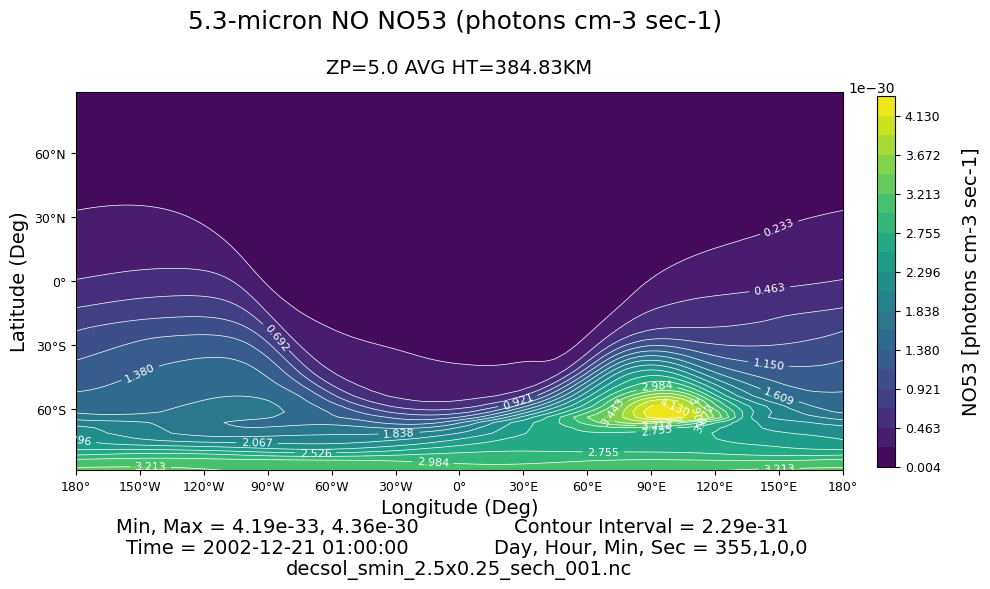

In [13]:
fig = gy.plt_lat_lon(datasets, 'NO53', time=t_val, level=5.0)
plt.show()

In [ ]:
fig = gy.plt_lat_lon(datasets, 'CO215', time=t_val, level=5.0)
plt.show()

## Cleanup

In [14]:
gy.close_datasets(datasets)
print('Datasets closed.')

Datasets closed.
